In [1]:
from __future__ import annotations

import anndata
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt

In [2]:
# note that this collection of batches is already intersected on the genes
anndata = sc.read(
    "data/pancreas.h5ad",
    backup_url="https://www.dropbox.com/s/qj1jlm9w10wmt0u/pancreas.h5ad?dl=1",
)
anndata

/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/anaconda3/envs/bibola/lib/python3.11/site-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


AnnData object with n_obs × n_vars = 14693 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [3]:
counts = anndata.obs["celltype"].value_counts()
counts.to_frame()

,count
celltype,
alpha,4214
beta,3354
ductal,1804
acinar,1368
not applicable,1154
delta,917
gamma,571
endothelial,289
activated_stellate,284


In [4]:
minority_classes = counts.index[-5:].tolist()  # get the minority classes
# actually subset
anndata = anndata[~anndata.obs["celltype"].isin(minority_classes)].copy()
# reorder according to abundance
anndata.obs["celltype"] = anndata.obs["celltype"].cat.reorder_categories(counts.index[:-5].tolist())
anndata.obs

,celltype,sample,n_genes,batch,n_counts,louvain
index,,,,,,
human1_lib1.final_cell_0001-0,acinar,Baron,3526,0,2.241100e+04,2
human1_lib1.final_cell_0002-0,acinar,Baron,4201,0,2.794900e+04,2
human1_lib1.final_cell_0003-0,acinar,Baron,2119,0,1.689200e+04,2
human1_lib1.final_cell_0004-0,acinar,Baron,2956,0,1.929900e+04,2
human1_lib1.final_cell_0005-0,acinar,Baron,2715,0,1.506700e+04,2
...,...,...,...,...,...,...
reads.29499-3,ductal,Wang,19950,3,1.056558e+06,10
reads.29500-3,ductal,Wang,19950,3,9.926309e+05,10
reads.29501-3,beta,Wang,19950,3,1.751338e+06,10


In [6]:
sc.pp.pca(anndata)
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

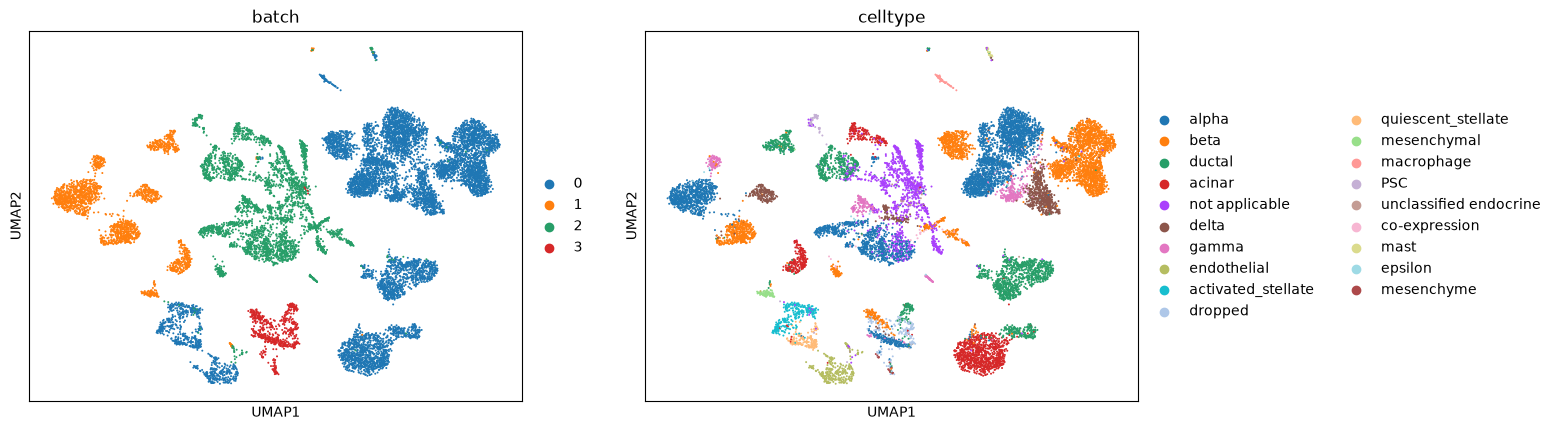

In [10]:
# original UMAP (without batch correction)
sc.pl.umap(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)

In [11]:
import torch

from sklearn.model_selection import RepeatedStratifiedKFold
from bibola.MLP import MultiBatchesMLP

In [12]:
batch_correction_model = MultiBatchesMLP(
    in_channels=anndata.obsm["X_pca"].shape[1],
    hidden_channels=[1024,],
    out_channels=50,
    n_batches=anndata.obs["batch"].nunique(),
    dropout=0.1,
)
batch_correction_model.train()

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-3): 4 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=50, bias=True)
      )
    )
  )
)

In [13]:
N_MINIBATCHES = 10
N_EPOCHS = 5

loader = RepeatedStratifiedKFold(
    n_splits=N_MINIBATCHES, # number of minibatches to train on
    n_repeats=N_EPOCHS, # number of epochs to train on
    random_state=42
)
loader

RepeatedStratifiedKFold(n_repeats=5, n_splits=10, random_state=42)

In [ ]:
batch_correction_model.train()

i = 0
for _, train_ids in loader.split(anndata.obs.index, anndata.obs["batch"]):
    if i%N_MINIBATCHES == 0:
        print(f"####### EPOCH {1+ i//N_MINIBATCHES} #######")
    
    X_train = anndata.obsm["X_pca"][train_ids]
    X_train = torch.tensor(X_train, dtype=torch.float32)
    
    batch_train = anndata.obs["batch"].values[train_ids].astype(int)
    batch_train = torch.tensor(batch_train, dtype=torch.int32)
    
    batch_correction_model.fit(
        X_train, batch_train, epochs=1, lr=1e-4,
        print_every=1, k_inter=5, k_intra=100, norm=1,
        loss_weights={"abs_lisa_loss":.25, "topology_loss": .75, "knn_loss": 2.}
    )

    i+=1

batch_correction_model.eval()

####### EPOCH 1 #######
Epoch 0, Loss: -1.178250789642334
Epoch 0, Loss: -1.0843284130096436
Epoch 0, Loss: -1.2400667667388916
Epoch 0, Loss: -1.191014289855957
Epoch 0, Loss: -1.2231862545013428
Epoch 0, Loss: -1.317182183265686
Epoch 0, Loss: -1.3515223264694214
Epoch 0, Loss: -1.3262547254562378
Epoch 0, Loss: -1.3429312705993652
Epoch 0, Loss: -1.3797457218170166
####### EPOCH 2 #######
Epoch 0, Loss: -1.4377028942108154
Epoch 0, Loss: -1.4306007623672485
Epoch 0, Loss: -1.4426062107086182
Epoch 0, Loss: -1.5285568237304688
Epoch 0, Loss: -1.5007634162902832
Epoch 0, Loss: -1.5465402603149414
Epoch 0, Loss: -1.560856580734253
Epoch 0, Loss: -1.5638015270233154
Epoch 0, Loss: -1.6068850755691528
Epoch 0, Loss: -1.6262435913085938
####### EPOCH 3 #######
Epoch 0, Loss: -1.649070382118225
Epoch 0, Loss: -1.7009484767913818
Epoch 0, Loss: -1.6796404123306274
Epoch 0, Loss: -1.6822689771652222
Epoch 0, Loss: -1.6473054885864258
Epoch 0, Loss: -1.7868866920471191
Epoch 0, Loss: -1.74469

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-3): 4 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=50, bias=True)
      )
    )
  )
)

In [15]:
anndata.obsm["X_corrected"] = batch_correction_model(
    torch.tensor(anndata.obsm["X_pca"], dtype=torch.float32),
    torch.tensor(anndata.obs["batch"].values.astype(int), dtype=torch.int32)
).detach().numpy()

from sklearn.decomposition import PCA

# we apply PCA to reduce the collinearity after the batch correction.
pca_model = PCA(n_components=50)
anndata.obsm["X_corrected"] = pca_model.fit_transform(anndata.obsm["X_corrected"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors'
    obsm: 'X_pca', 'X_umap', 'X_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [16]:
sc.pp.neighbors(anndata, use_rep="X_corrected", key_added="neighbors_corrected")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected", key_added="umap_corrected")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities'

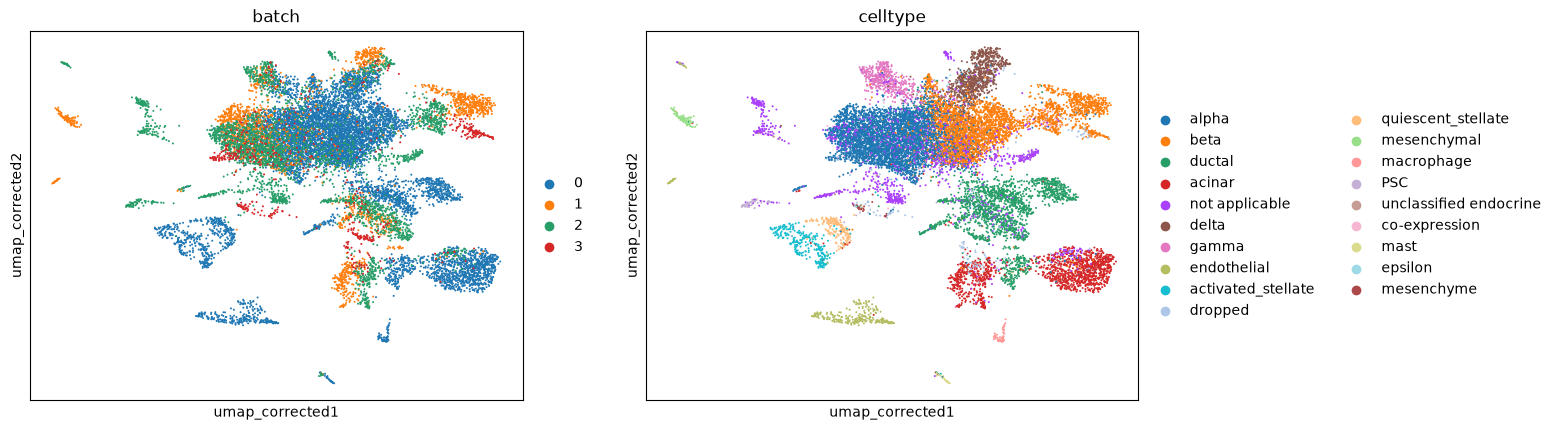

In [ ]:
sc.pl.embedding(anndata, basis="umap_corrected", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola

In [18]:
from harmonypy import run_harmony

In [19]:
anndata.obsm["X_pca_harmony"] = run_harmony(anndata.obsm["X_pca"], anndata.obs, "batch").Z_corr
anndata.obsm["X_pca_harmony"]

2026-08-04 16:20:24,717 - harmonypy - INFO - Running Harmony
2026-08-04 16:20:24,718 - harmonypy - INFO -   Parameters:
2026-08-04 16:20:24,718 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-04 16:20:24,719 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-04 16:20:24,719 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-04 16:20:24,720 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-04 16:20:24,720 - harmonypy - INFO -     nclust: 100
2026-08-04 16:20:24,720 - harmonypy - INFO -     block_size: 0.05
2026-08-04 16:20:24,721 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-04 16:20:24,721 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-08-04 16:20:24,722 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-04 16:20:24,722 - harmonypy - INFO -     verbose: True
2026-08-04 16:20:24,723 - harmonypy - INFO -     random_state: 0
2026-08-04 16:20:24,723 - harmonypy - INFO -   Data: 50 PCs × 14662 cells
2026-08-04 16:20:24,724 - harmonypy - INFO -

array([[  0.15425171,  -4.53972244,  -8.52065468, ...,  -0.38841876,
         -1.45698595,   0.08615991],
       [  3.89552402,  -4.51804066, -10.26223946, ...,  -1.12404025,
          0.90807426,   0.02703966],
       [ -3.71449828,  -4.54087257,  -6.43288279, ...,  -0.76113915,
          0.75945079,   0.08842079],
       ...,
       [  2.96661663,  10.92668152,   5.37792253, ...,   4.19615793,
          1.68354046,   0.28366753],
       [ 14.31705666,  -1.82588816, -12.1900053 , ...,   1.48150325,
          0.90651804,   1.02317023],
       [  3.00160837,  12.04156685,   4.41478348, ...,   0.0424562 ,
          0.6069088 ,   1.26845121]], shape=(14662, 50))

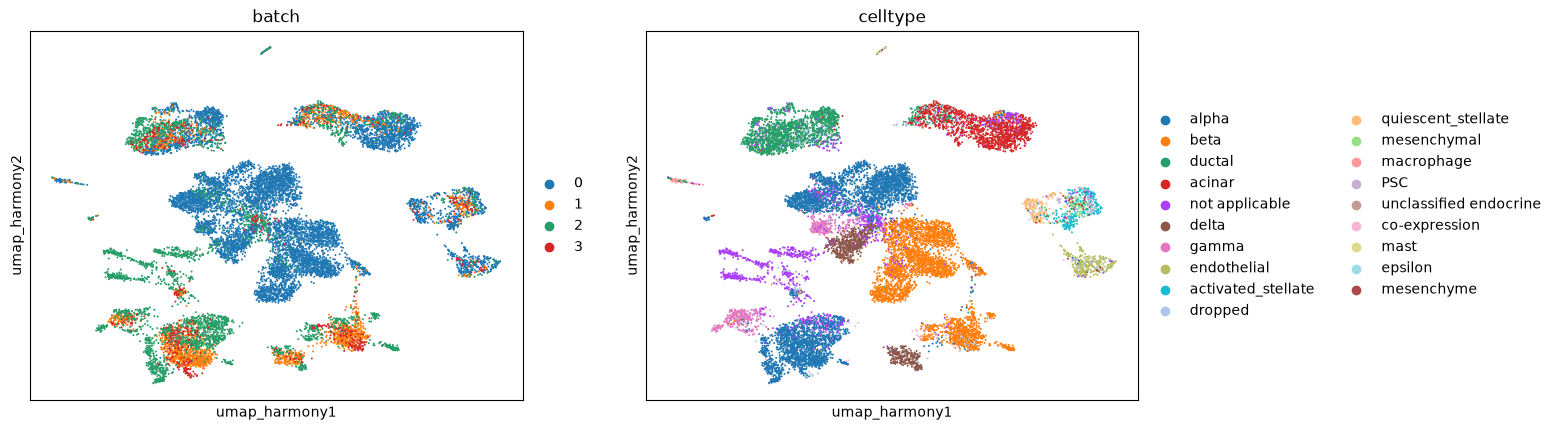

In [21]:
sc.pp.neighbors(anndata, use_rep="X_pca_harmony", key_added="neighbors_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_harmony", key_added="umap_harmony")
sc.pl.embedding(anndata, color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy, basis="umap_harmony")
# UMAP after batch correction via harmony

In [22]:
# We can even consider to run the bibola workflow starting from harmony correction, instead of PCA.
# This in order to have a warmer initializzation of the gradient, since the data is already well integrated and we just need to refine the integration at a local level..
# In this case, we will prioritize the spatial autocorrelation (LIBSA) loss since the batches are already "close" enough.

In [23]:
batch_correction_model = MultiBatchesMLP(
    in_channels=anndata.obsm["X_pca_harmony"].shape[1],
    hidden_channels=[1024,],
    out_channels=50,
    n_batches=anndata.obs["batch"].nunique(),
    dropout=0.1,
)
batch_correction_model.train()

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-3): 4 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=50, bias=True)
      )
    )
  )
)

In [ ]:
batch_correction_model.train()

i = 0
for _, train_ids in loader.split(anndata.obs.index, anndata.obs["batch"]):
    if i%N_MINIBATCHES == 0:
        print(f"####### EPOCH {1+ i//N_MINIBATCHES} #######")
    
    X_train = anndata.obsm["X_pca_harmony"][train_ids] # here the input is the harmony corrected data, instead of PCA
    X_train = torch.tensor(X_train, dtype=torch.float32)
    
    batch_train = anndata.obs["batch"].values[train_ids].astype(int)
    batch_train = torch.tensor(batch_train, dtype=torch.int32)
    
    batch_correction_model.fit(
        X_train, batch_train, epochs=1, lr=1e-4,
        print_every=1, k_inter=5, k_intra=100, norm=1,
        loss_weights={"abs_lisa_loss":.5, "topology_loss": .25, "knn_loss": .25}
    )

    i+=1

batch_correction_model.eval()

####### EPOCH 1 #######
Epoch 0, Loss: -0.27756085991859436
Epoch 0, Loss: -0.2633182108402252
Epoch 0, Loss: -0.27479293942451477
Epoch 0, Loss: -0.2650463581085205
Epoch 0, Loss: -0.27215293049812317
Epoch 0, Loss: -0.28625667095184326
Epoch 0, Loss: -0.2876806855201721
Epoch 0, Loss: -0.2891741394996643
Epoch 0, Loss: -0.2989019453525543
Epoch 0, Loss: -0.29449522495269775
####### EPOCH 2 #######
Epoch 0, Loss: -0.302775502204895
Epoch 0, Loss: -0.3027825951576233
Epoch 0, Loss: -0.30139273405075073
Epoch 0, Loss: -0.3098560571670532
Epoch 0, Loss: -0.3109027147293091
Epoch 0, Loss: -0.3155418932437897
Epoch 0, Loss: -0.3132783770561218
Epoch 0, Loss: -0.31517961621284485
Epoch 0, Loss: -0.3133898973464966
Epoch 0, Loss: -0.31883084774017334
####### EPOCH 3 #######
Epoch 0, Loss: -0.32363957166671753
Epoch 0, Loss: -0.33303138613700867
Epoch 0, Loss: -0.32520532608032227
Epoch 0, Loss: -0.32248133420944214
Epoch 0, Loss: -0.3290543854236603
Epoch 0, Loss: -0.32959339022636414
Epoch 

MultiBatchesMLP(
  (mlps): ModuleList(
    (0-3): 4 x BatchMLP(
      (sequential): Sequential(
        (0): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
        (1): MLP(
          (0): Linear(in_features=50, out_features=1024, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
        (2): Linear(in_features=1024, out_features=50, bias=True)
      )
    )
  )
)

In [25]:
anndata.obsm["X_corrected_after_harmony"] = batch_correction_model(
    torch.tensor(anndata.obsm["X_pca_harmony"], dtype=torch.float32),
    torch.tensor(anndata.obs["batch"].values.astype(int), dtype=torch.int32)
).detach().numpy()

from sklearn.decomposition import PCA

pca_model = PCA(n_components=50)
anndata.obsm["X_corrected_after_harmony"] = pca_model.fit_transform(anndata.obsm["X_corrected_after_harmony"])
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities'

In [26]:
sc.pp.neighbors(anndata, use_rep="X_corrected_after_harmony", key_added="neighbors_corrected_after_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected_after_harmony", key_added="umap_corrected_after_harmony")
anndata

AnnData object with n_obs × n_vars = 14662 × 2448
    obs: 'celltype', 'sample', 'n_genes', 'batch', 'n_counts', 'louvain'
    var: 'n_cells-0', 'n_cells-1', 'n_cells-2', 'n_cells-3'
    uns: 'celltype_colors', 'louvain', 'neighbors', 'pca', 'sample_colors', 'umap', 'batch_colors', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors_harmony_distances', 'neighbors_harmony_connectivities', 'neighbors_corrected_after_harmony_distances', 'neighbors_corrected_after_harmony_connectivities'

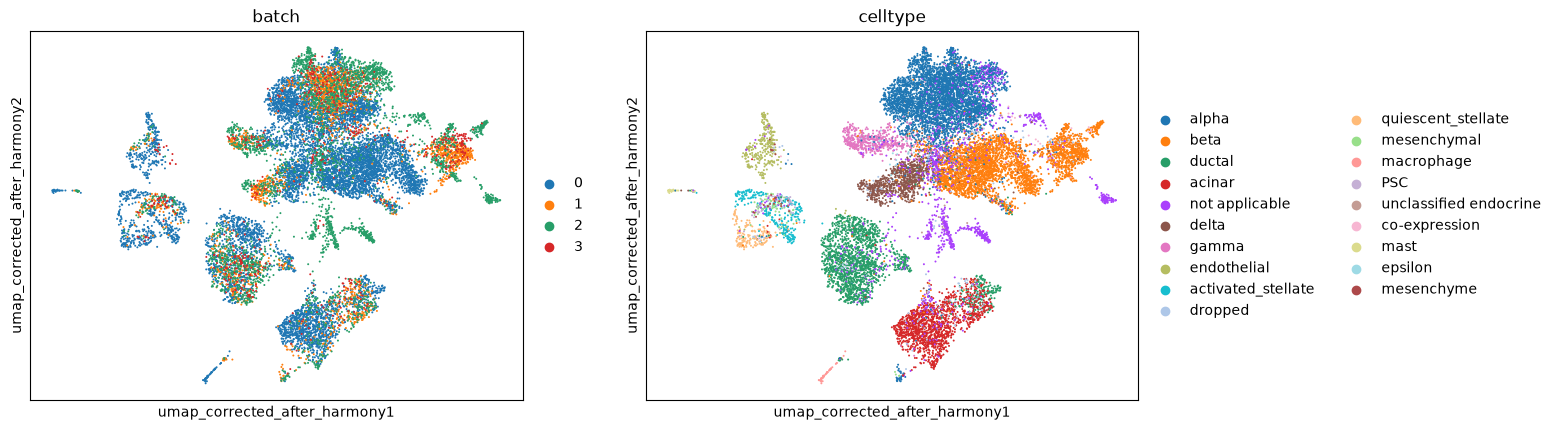

In [ ]:
sc.pl.embedding(anndata, basis="umap_corrected_after_harmony", color=["batch", "celltype"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola, starting from harmony
# we see an improvement in the integration of the batches, and a better separation of the cell types, compared to harmony alone.